In [1]:
# Libraries for all the tasks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


def check_nan(X, nan_symbol = np.nan):
    return [(X_train[c]==nan_symbol).sum() for c in X_train.columns]

## Explanations for linear regression

The task is to add code below to complete the calculation of explanations for a linear regression model (feature importance).

Dataset: predict an individual's insurance charge given features such as age, gender and whether the person is a smoker. 

*If there's problems with loading the data, download it from the original source.*

Source: https://www.kaggle.com/datasets/mirichoi0218/insurance 

R2: 0.68


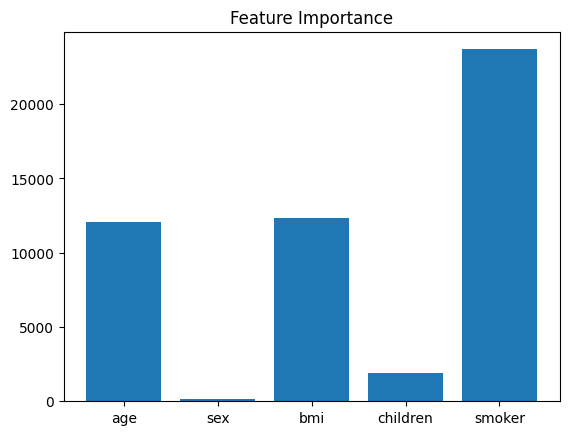

In [6]:
# Load the dataset
data = pd.read_csv("data/insurance.csv")

X = data.drop(['charges'],axis=1)
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# Handling missing values
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train_imputed = imp_mean.fit_transform(X_train)
X_test_imputed = imp_mean.fit_transform(X_test)

# Standardizing the training data-clf-students
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_train_scaled

X_test_scaled = scaler.fit_transform(X_test_imputed)

# Fit the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Finish the task
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_pred, y_test)

feature_importance = {feature: model.coef_[i] for i, feature in enumerate(X.keys())}

print(f"R2: {r2:.2f}")

fig, ax = plt.subplots()

ax.bar(feature_importance.keys(), feature_importance.values())
ax.set_title('Feature Importance')

plt.savefig("linear_regression.pdf", format="pdf", bbox_inches="tight")

## Explanations for decision tree and random forest

The task is to add code below to complete the calculation of explanations for tree-based models (decision tree and random forest).

Dataset: identify patients at risk of heart disease using the heart disease dataset. Feature importance explanations can determine the key factors for predicting heart disease, enabling more targeted healthcare interventions.

*If there's problems with loading the data, download it from the source.*

Source:https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset 

Accuracy score of  decision tree: 0.96


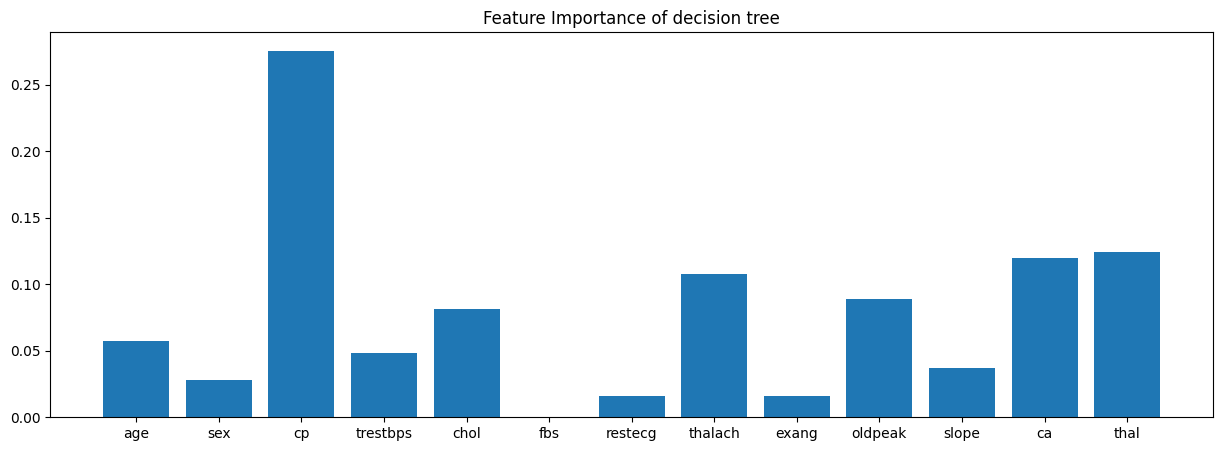

In [3]:
data = pd.read_csv("data/heart.csv")

X = data.drop(['target'],axis=1)
y = data['target']

features = np.array(X.keys())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

## Decision tree
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Derive feature importances
feature_importances_tree = clf.feature_importances_

# Plot the feature importances
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(features, feature_importances_tree)
ax.set_title('Feature Importance of decision tree')

plt.savefig("decision_tree.pdf", format="pdf", bbox_inches="tight")

# Evaluation
y_pred = clf.predict(X_test)
acc = accuracy_score(y_pred, y_test)
print(f"Accuracy score of  decision tree: {acc:.2f}")

Accuracy score of  decision tree: 0.98


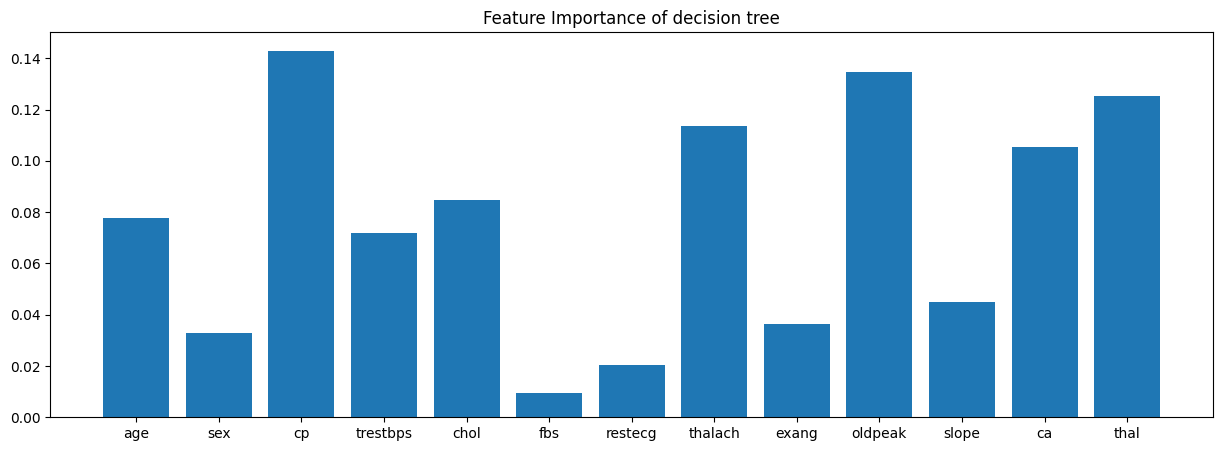

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

## Decision tree
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Derive feature importances
feature_importances_forest = clf.feature_importances_

# Plot the feature importances
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(features, feature_importances_forest)
ax.set_title('Feature Importance of decision tree')

plt.savefig("random_forest.pdf", format="pdf", bbox_inches="tight")

# Evaluation
y_pred = clf.predict(X_test)
acc = accuracy_score(y_pred, y_test)
print(f"Accuracy score of  decision tree: {acc:.2f}")

## Top5 features and model retraining

In [5]:
# Top5 most important features in each model
top5_tree = features[np.argsort(feature_importances_tree)][:-6:-1]
top5_forest = features[np.argsort(feature_importances_forest)][:-6:-1]
print(f"Top 5 features tree: {top5_tree}")
print(f"Top 5 features forest: {top5_forest}")

# Retraining 
X = data[top5_forest]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_test)
acc = accuracy_score(y_pred, y_test)
print(f"Accuracy score of  decision tree: {acc:.2f}")

Top 5 features tree: ['cp' 'thal' 'ca' 'thalach' 'oldpeak']
Top 5 features forest: ['cp' 'oldpeak' 'thal' 'thalach' 'ca']
Accuracy score of  decision tree: 0.98


The accuracy has not changed more than 1%, so there is no significant increase/decrease.

**Do I think feature importance is usefull?**

Yes, I do think that these feature importance scores are useful. For example, in the last assignment we checked whether only using the top 5 features significantly decreases/increases our accuracy, this can give us an insight on whether our original model had overfitted. In addition, these feature importances increase the interpretability of our model, and make it so they can be checked by domain experts.

**Would I trust feature importances?**

Not in every case. In the case our model has heavily overfitted to the data we can assume that our feature importance is not that reliable to interpret. In addition, we would like to have a lot of data so we can be more sure our feature importances actually generalize to the whole population, we could apply significance testing using either bayesian or frequentist statistics (p-values, bayes factors).